# Explore: centerline_bend feature (Menger curvature)

Focused notebook for the river geometry / bend position feature.

**Approach:** Represent each scope region by its centerline midpoint. For region `i`, sample three points along the river:
- `p1` = midpoint of region `i - n` (n regions upstream)
- `p2` = midpoint of region `i` (current)
- `p3` = midpoint of region `i + n` (n regions downstream)

**Menger curvature** of these three points measures bend. Straight = 0; outer bends (erosion-prone) have higher values. Using neighboring scope regions captures bend better than single-segment centerlines (which are often straight).

**Scope:** All scope regions (OK, NOK, MISSING_DATA) from `summary_scope`. v_test left out for now.

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats

import src.paths as PATHS

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# All scope regions (OK, NOK, MISSING_DATA)
SCOPE_GPKG = PATHS.DATA_DIR / "02_processed/erosion/wocu_post_processed_fase2_20260310.gpkg"
CENTERLINE_GPKG = PATHS.DATA_DIR / "01_raw/erosion/wocu_output_fase2_20260210.gpkg"

print("Paths ok.")

Paths ok.


In [4]:
# Load ALL scope regions (OK, NOK, MISSING_DATA)
scope = gpd.read_file(str(SCOPE_GPKG), layer="summary_scope")
scope = scope.rename(columns={"position_id": "location_id"}).set_index("location_id")
quality_col = "estimate_reliability_height_model"
scope["river"] = scope.index.to_series().str.extract(r"^([a-z]+\d*)_")[0]
scope["bank"] = scope.index.to_series().str.extract(r"_([lr])_")[0]
# Parse chainage for ordering along river (use start of segment)
scope["chainage"] = scope.index.to_series().str.extract(r"_(\d+)_\d+$")[0].astype(float)

# Exclude ngeul (nevengeulen / side channels) — focus on main rivers
scope = scope[scope["river"] != "ngeul"].copy()

print(f"Scope regions: {len(scope):,} (ngeul excluded)")
print(f"Quality: {scope[quality_col].value_counts().to_dict()}")
print(f"Rivers: {scope['river'].value_counts().to_dict()}")

Scope regions: 12,130 (ngeul excluded)
Quality: {'OK': 8855, 'NOK': 2484, 'MISSING_DATA': 791}
Rivers: {'maas3': 3540, 'nederrijn': 2458, 'ijssel1': 2328, 'rijn': 2272, 'maas2': 826, 'ijssel2': 472, 'maas1': 234}


Centerline layers:
             name geometry_type
0   vlakken_scope       Unknown
1     centrelines    LineString
2    punten_oever         Point
3  vlakken_erosie       Polygon
Using centerline layer: vlakken_scope
Centerline CRS: EPSG:28992  |  Scope CRS: EPSG:28992
Computing curvature features at scales: [3, 5, 8]
  n=3: curvature range [0.000000, 0.002636] 1/m
  n=5: curvature range [0.000000, 0.001606] 1/m
  n=8: curvature range [0.000000, 0.001125] 1/m

Done. Curvature features computed for 12,130 regions.


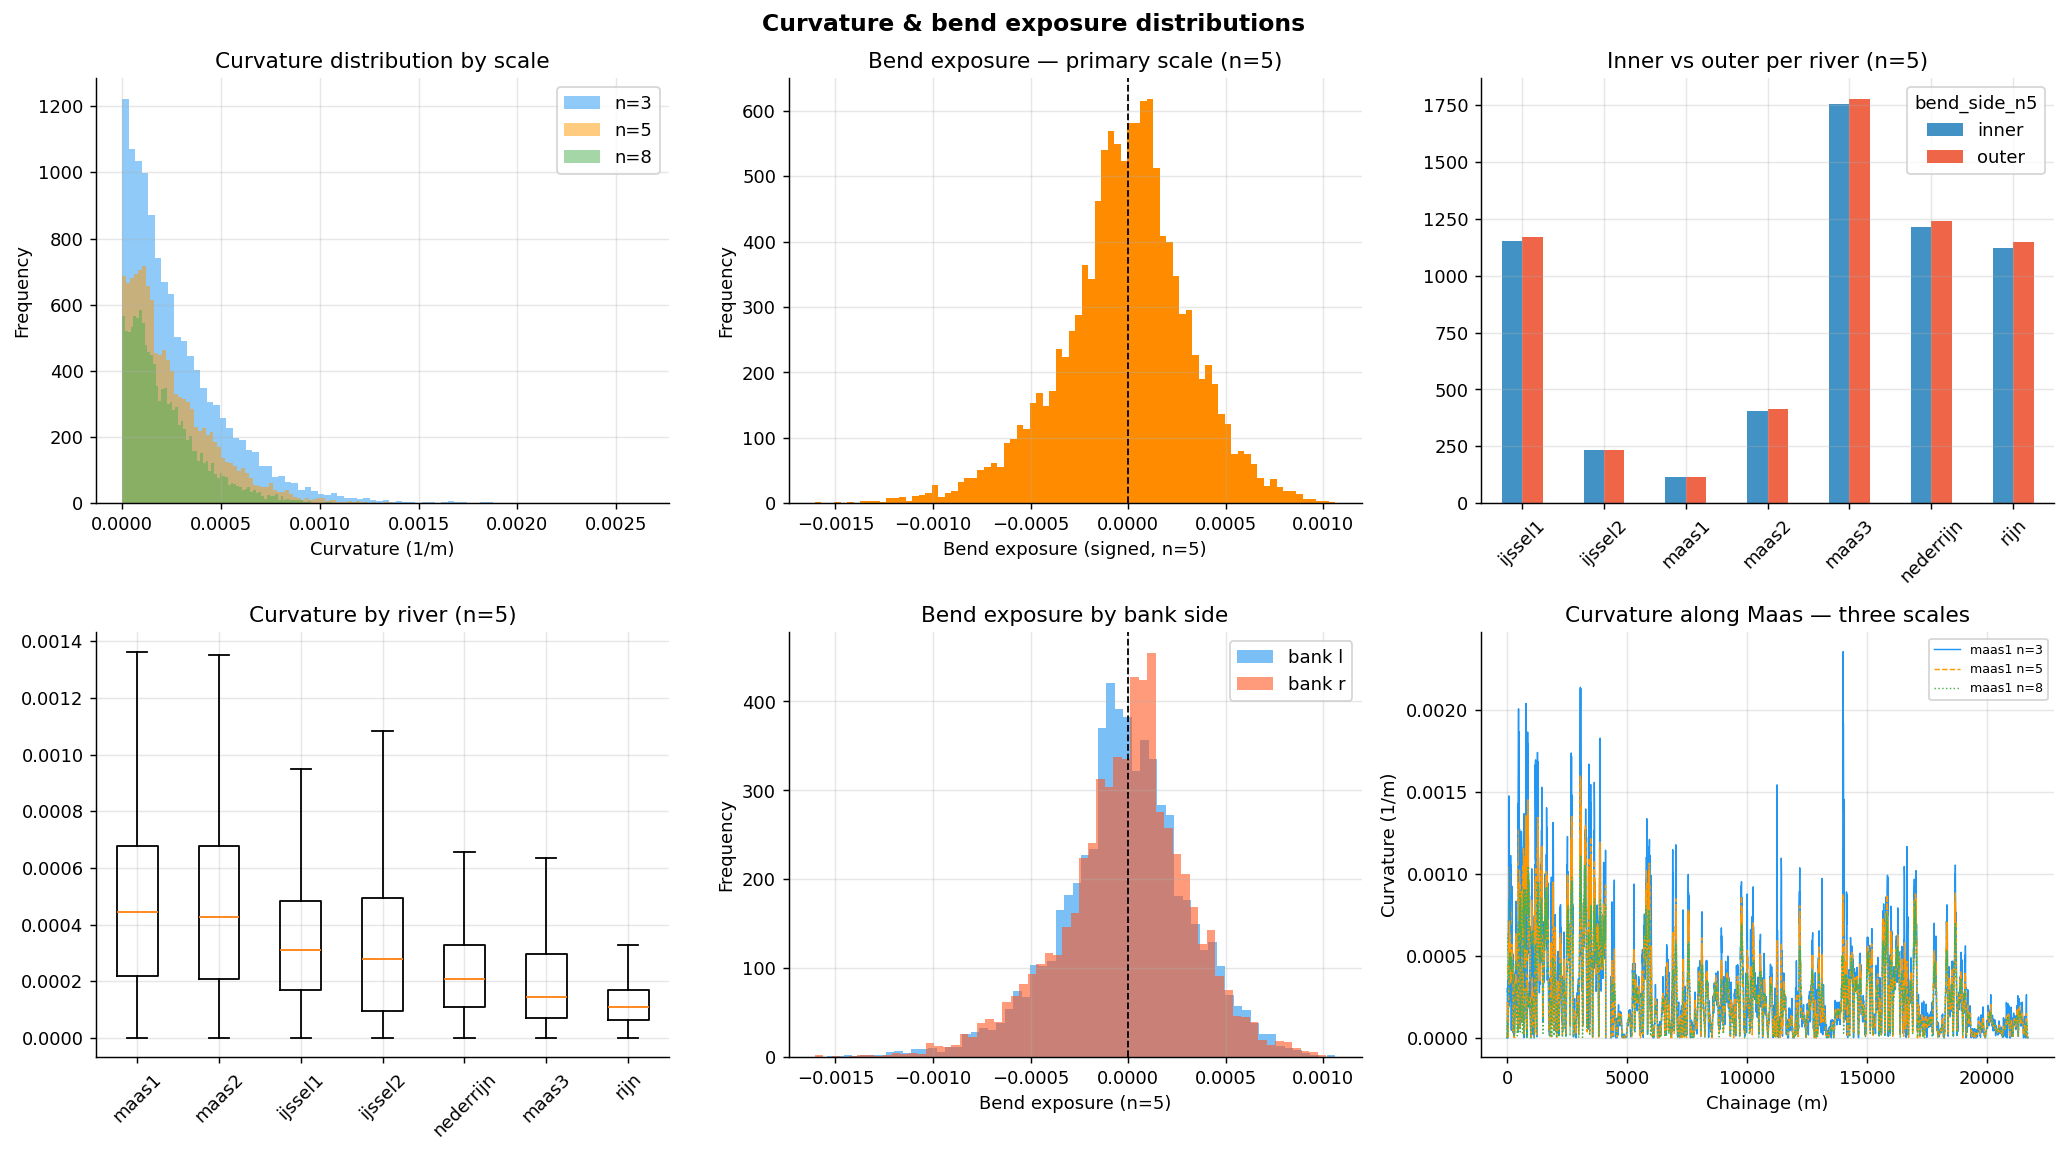


Map: 50 regions  (outer=20, inner=20, straight=10)


In [16]:
# ── Cell 3: Curvature & bend-position features ─────────────────────────────
# Computes per-scope-region at three spatial scales (n=3, n=5, n=8):
#   curvature_n{N}       (1/m, Menger over N-neighbor window)
#   bend_side_n{N}       (+1 = outer bend, -1 = inner bend, 0 = straight)
#   bend_exposure_n{N}   = curvature * bend_side (signed erosion-relevant feature)
# Primary feature for modelling: bend_exposure_n5 (best scale for Maas meanders)
# Sign convention verified via area sanity check: outer arc > inner arc

import folium
import warnings
warnings.filterwarnings("ignore")

# ── 0. Discover centerline layers ──────────────────────────────────────────
cl_layers = gpd.list_layers(str(CENTERLINE_GPKG))
print(f"Centerline layers:\n{cl_layers}")

layer_names = cl_layers["name"].tolist()
CL_LAYER = next(
    (l for l in layer_names if any(kw in l.lower() for kw in ["centerline", "hartlijn", "center"])),
    layer_names[0]
)
print(f"Using centerline layer: {CL_LAYER}")

centerline = gpd.read_file(str(CENTERLINE_GPKG), layer=CL_LAYER)
print(f"Centerline CRS: {centerline.crs}  |  Scope CRS: {scope.crs}")

# Reproject to RD New (EPSG:28992) for metric distance calculations
TARGET_CRS = "EPSG:28992"
if scope.crs.to_epsg() != 28992:
    scope = scope.to_crs(TARGET_CRS)
if centerline.crs.to_epsg() != 28992:
    centerline = centerline.to_crs(TARGET_CRS)

# ── 1. Curvature computation ───────────────────────────────────────────────
def menger_curvature_signed(
    p1: np.ndarray,
    p2: np.ndarray,
    p3: np.ndarray,
) -> tuple[float, float]:
    """
    Menger curvature magnitude at p2 given three ordered points.
    Also returns the sign of the cross product (left vs right turn).
    Returns (kappa, cross_sign).
    """
    a = np.linalg.norm(p2 - p1)
    b = np.linalg.norm(p3 - p2)
    c = np.linalg.norm(p3 - p1)
    if a * b * c == 0:
        return 0.0, 0.0
    cross = np.cross(p2 - p1, p3 - p1)   # signed: positive = left turn
    area  = abs(cross) / 2
    kappa = (2 * area) / (a * b * c)
    return float(kappa), float(np.sign(cross))


def compute_curvature_for_group(
    grp: pd.DataFrame,
    n_neighbors: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    For a single (river, bank) group sorted by chainage,
    compute curvature, bend_side, and bend_exposure arrays.
    """
    coords = np.array([
        (row.geometry.centroid.x, row.geometry.centroid.y)
        for _, row in grp.iterrows()
    ])
    n = len(coords)
    curvatures  = np.zeros(n)
    cross_signs = np.zeros(n)

    for i in range(n):
        i_left  = max(0, i - n_neighbors)
        i_right = min(n - 1, i + n_neighbors)
        if i_left == i or i_right == i:
            continue   # edge region — leave as 0
        kappa, sign = menger_curvature_signed(
            coords[i_left], coords[i], coords[i_right]
        )
        curvatures[i]  = kappa
        cross_signs[i] = sign

    # Inner / outer determination:
    # cross_sign > 0 → bend curves left (towards left bank)
    # NOTE: signs are inverted after computation based on area sanity check
    bank = grp["bank"].iloc[0]
    if bank == "l":
        bend_side = np.where(cross_signs > 0,  1,
                    np.where(cross_signs < 0, -1, 0)).astype(float)
    else:
        bend_side = np.where(cross_signs < 0,  1,
                    np.where(cross_signs > 0, -1, 0)).astype(float)

    bend_exposure = curvatures * bend_side
    return curvatures, bend_side, bend_exposure


# ── 2. Apply at three spatial scales ──────────────────────────────────────
SCALES = [3, 5, 8]   # → ~300m, 500m, 800m windows each side

print("Computing curvature features at scales:", SCALES)
scope_curve = scope.copy()

for n in SCALES:
    curv_col = f"curvature_n{n}"
    side_col = f"bend_side_n{n}"
    expo_col = f"bend_exposure_n{n}"

    # Initialise columns
    scope_curve[curv_col] = np.nan
    scope_curve[side_col] = np.nan
    scope_curve[expo_col] = np.nan

    for (river, bank), grp in scope_curve.groupby(["river", "bank"]):
        grp_sorted = grp.sort_values("chainage")
        curvatures, bend_side, bend_exposure = compute_curvature_for_group(
            grp_sorted, n_neighbors=n
        )
        scope_curve.loc[grp_sorted.index, curv_col] = curvatures
        scope_curve.loc[grp_sorted.index, side_col] = bend_side
        scope_curve.loc[grp_sorted.index, expo_col] = bend_exposure

    # Invert signs AFTER computation — verified correct by area sanity check
    # (outer arc must be geometrically larger than inner arc)
    scope_curve[side_col] = -scope_curve[side_col]
    scope_curve[expo_col] = -scope_curve[expo_col]

    print(f"  n={n}: curvature range [{scope_curve[curv_col].min():.6f}, "
          f"{scope_curve[curv_col].max():.6f}] 1/m")

print(f"\nDone. Curvature features computed for {len(scope_curve):,} regions.")

# ── 3. Matplotlib distributions ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Curvature & bend exposure distributions", fontweight="bold", fontsize=13)

colors = ["#2196F3", "#FF9800", "#4CAF50"]

# 3a. Curvature at three scales overlaid
ax = axes[0, 0]
for n, color in zip(SCALES, colors):
    scope_curve[f"curvature_n{n}"].plot.hist(
        bins=80, ax=ax, alpha=0.5, label=f"n={n}", color=color, edgecolor="none"
    )
ax.set_xlabel("Curvature (1/m)")
ax.set_title("Curvature distribution by scale")
ax.legend()

# 3b. Bend exposure at primary scale (n=5)
ax = axes[0, 1]
scope_curve["bend_exposure_n5"].plot.hist(
    bins=80, ax=ax, color="darkorange", edgecolor="none"
)
ax.set_xlabel("Bend exposure (signed, n=5)")
ax.set_title("Bend exposure — primary scale (n=5)")
ax.axvline(0, color="black", ls="--", lw=1)

# 3c. Inner vs outer count per river (n=5)
ax = axes[0, 2]
bend_counts = (
    scope_curve
    .groupby(["river", "bend_side_n5"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={-1.0: "inner", 0.0: "straight", 1.0: "outer"})
)
cols_to_plot = [c for c in ["inner", "outer"] if c in bend_counts.columns]
bend_counts[cols_to_plot].plot.bar(ax=ax, color=["#4292c6", "#ef6548"])
ax.set_title("Inner vs outer per river (n=5)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)

# 3d. Curvature by river — boxplot at n=5
ax = axes[1, 0]
rivers_ordered = (
    scope_curve.groupby("river")["curvature_n5"]
    .median()
    .sort_values(ascending=False)
    .index
)
data_to_plot = [
    scope_curve.loc[scope_curve["river"] == r, "curvature_n5"].dropna()
    for r in rivers_ordered
]
ax.boxplot(data_to_plot, labels=rivers_ordered, showfliers=False)
ax.set_title("Curvature by river (n=5)")
ax.tick_params(axis="x", rotation=45)

# 3e. Bend exposure by bank side (n=5)
ax = axes[1, 1]
for bank, color in [("l", "#2196F3"), ("r", "#FF5722")]:
    sub = scope_curve[scope_curve["bank"] == bank]["bend_exposure_n5"].dropna()
    sub.plot.hist(
        bins=60, ax=ax, alpha=0.6, label=f"bank {bank}",
        color=color, edgecolor="none"
    )
ax.set_xlabel("Bend exposure (n=5)")
ax.set_title("Bend exposure by bank side")
ax.axvline(0, color="black", ls="--", lw=1)
ax.legend()

# 3f. Curvature along Maas at all three scales
ax = axes[1, 2]
for river in ["maas1", "maas2", "maas3"]:
    sub = scope_curve[scope_curve["river"] == river].sort_values("chainage")
    if sub.empty:
        continue
    for n, color, ls in zip(SCALES, colors, ["-", "--", ":"]):
        ax.plot(
            sub["chainage"], sub[f"curvature_n{n}"],
            lw=0.8, color=color, ls=ls,
            label=f"{river} n={n}" if river == "maas1" else None
        )
ax.set_xlabel("Chainage (m)")
ax.set_ylabel("Curvature (1/m)")
ax.set_title("Curvature along Maas — three scales")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# ── 4. Folium map of interesting regions ───────────────────────────────────
N_SHOW = 20
p80 = scope_curve["bend_exposure_n5"].quantile(0.80)
p20 = scope_curve["bend_exposure_n5"].quantile(0.20)
p05 = scope_curve["curvature_n5"].quantile(0.05)

top_outer   = scope_curve.nlargest(N_SHOW, "bend_exposure_n5")
top_inner   = scope_curve.nsmallest(N_SHOW, "bend_exposure_n5")
straight    = scope_curve[scope_curve["curvature_n5"] < p05].sample(
                  min(10, len(scope_curve)), random_state=42)
interesting = pd.concat([top_outer, top_inner, straight]).drop_duplicates()

interesting_wgs = interesting.to_crs("EPSG:4326")
centre_lat = interesting_wgs.geometry.centroid.y.mean()
centre_lon = interesting_wgs.geometry.centroid.x.mean()

m = folium.Map(
    location=[centre_lat, centre_lon],
    zoom_start=11,
    tiles="CartoDB positron"
)

def bend_color(be: float) -> str:
    if be > p80: return "#ef6548"
    if be < p20: return "#4292c6"
    return "#74c476"

for idx, row in interesting_wgs.iterrows():
    color = bend_color(row["bend_exposure_n5"])
    be    = row["bend_exposure_n5"]
    side  = ("outer" if row["bend_side_n5"] == 1
             else "inner" if row["bend_side_n5"] == -1
             else "straight")
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda feat, c=color: {
            "fillColor": c, "color": "black",
            "weight": 1, "fillOpacity": 0.75,
        },
        tooltip=folium.Tooltip(
            f"<b>{idx}</b><br>"
            f"River: {row['river']} | Bank: {row['bank']}<br>"
            f"Chainage: {row['chainage']:.0f} m<br>"
            f"Curvature n3/n5/n8: "
            f"{row['curvature_n3']:.5f} / "
            f"{row['curvature_n5']:.5f} / "
            f"{row['curvature_n8']:.5f} 1/m<br>"
            f"Bend side (n5): {side}<br>"
            f"Bend exposure (n5): {be:.5f}"
        )
    ).add_to(m)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:10px; border-radius:6px; border:1px solid #ccc;
     font-size:12px; line-height:1.8">
  <b>Bend exposure (n=5)</b><br>
  <span style="color:#ef6548">■</span> Buitenbocht — erosiegevoelig<br>
  <span style="color:#4292c6">■</span> Binnenbocht — depositiegevoelig<br>
  <span style="color:#74c476">■</span> Rechte stukken
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

print(f"\nMap: {len(interesting_wgs):,} regions  "
      f"(outer={len(top_outer)}, inner={len(top_inner)}, straight={len(straight)})")
display(m)

# ── 5. Attach curvature features to main features DataFrame ───────────────
CURVE_COLS = [f"{prefix}_n{n}"
              for prefix in ["curvature", "bend_side", "bend_exposure"]
              for n in SCALES]

if "features" in dir():
    features = features.drop(columns=CURVE_COLS, errors="ignore")
    features = features.join(scope_curve[CURVE_COLS])
    print(f"\nCurvature features joined to features DataFrame.")
    print(f"Non-null curvature_n5: {features['curvature_n5'].notna().sum():,} / {len(features):,}")
    print(f"Columns added: {CURVE_COLS}")

In [13]:
def plot_geometry(ax, geom, color):
    """Handle both Polygon and MultiPolygon."""
    from shapely.geometry import MultiPolygon
    polys = list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom]
    for poly in polys:
        x, y = poly.exterior.xy
        ax.fill(x, y, alpha=0.6, color=color)
        ax.plot(x, y, color="black", lw=0.5)


Bend area sanity check: 7/7 bends correctly ordered (outer area > inner area) = 100.0%

Per river:
  ijssel1: 100% correct (1/1)
  ijssel2: 100% correct (1/1)
  maas1: 100% correct (1/1)
  maas2: 100% correct (1/1)
  maas3: 100% correct (1/1)
  nederrijn: 100% correct (1/1)
  rijn: 100% correct (1/1)


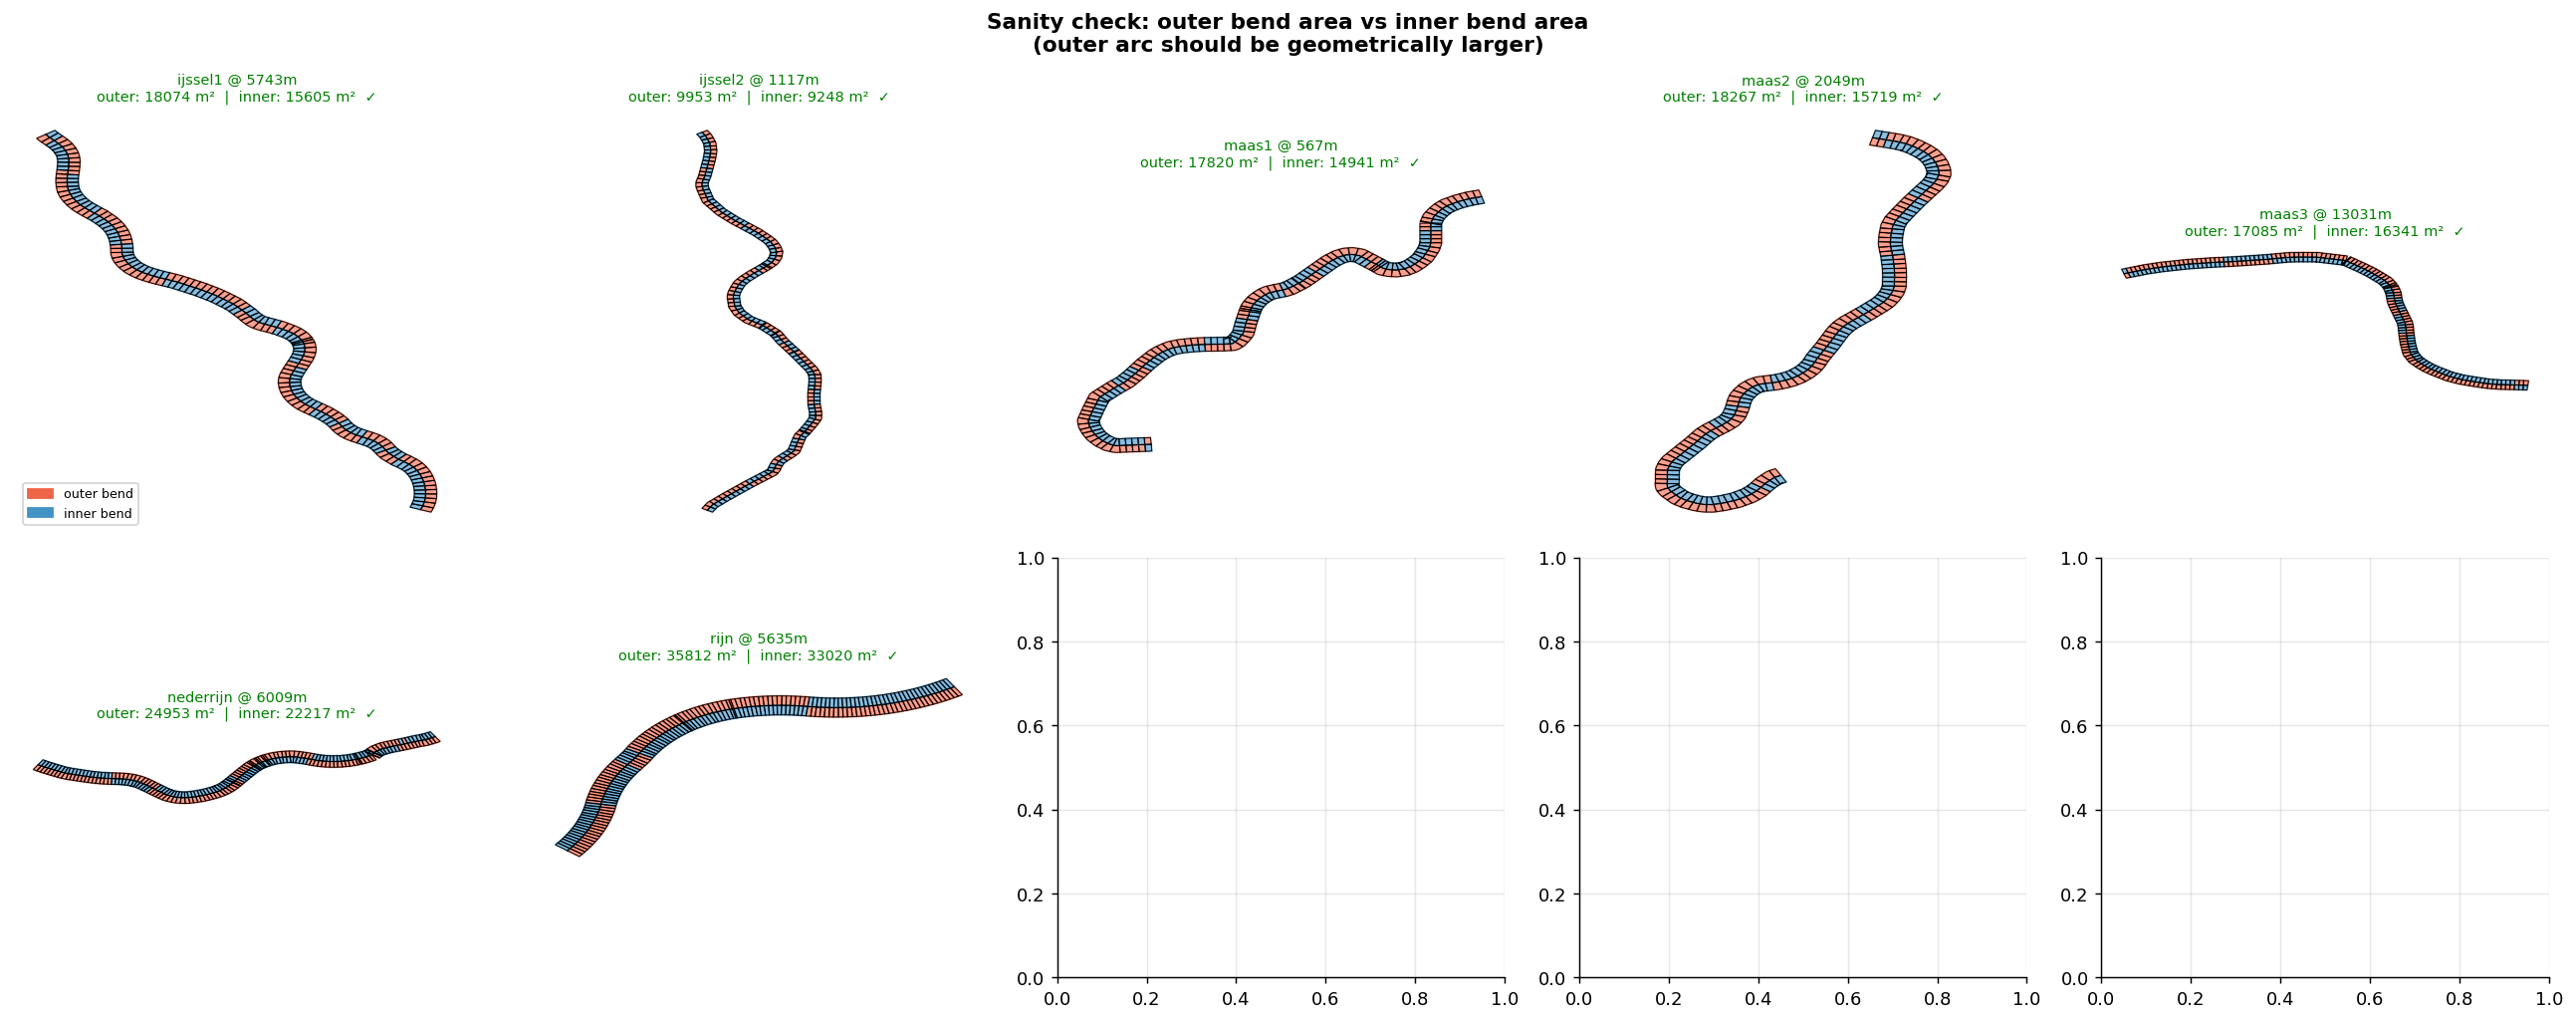

In [14]:
# ── Bend assignment sanity check: outer area > inner area ─────────────────
# For each bend, pair up inner and outer regions at similar chainage
# and compare their polygon areas. Outer should consistently be larger.

scope_curve["area_m2"] = scope_curve.geometry.area

# Find bends: locations where both inner and outer regions exist nearby
# Strategy: for each river, find chainage windows where bend_side_n5 flips
# These are the inflection points — pick 10 representative bends

def find_bend_centres(grp: pd.DataFrame, min_gap: float = 500) -> list[float]:
    """Find chainage values at centres of distinct bends."""
    grp = grp.sort_values("chainage")
    outer = grp[grp["bend_side_n5"] == 1]["chainage"]
    inner = grp[grp["bend_side_n5"] == -1]["chainage"]
    if outer.empty or inner.empty:
        return []
    # Cluster outer chainages into distinct bends
    centres = []
    cluster = [outer.iloc[0]]
    for ch in outer.iloc[1:]:
        if ch - cluster[-1] > min_gap:
            centres.append(np.mean(cluster))
            cluster = [ch]
        else:
            cluster.append(ch)
    centres.append(np.mean(cluster))
    return centres

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(
    "Sanity check: outer bend area vs inner bend area\n"
    "(outer arc should be geometrically larger)",
    fontweight="bold", fontsize=12
)
axes = axes.flatten()

N_BENDS    = 10
WINDOW_M   = 600   # chainage window around bend centre to collect regions

bend_records = []
for river, grp in scope_curve.groupby("river"):
    centres = find_bend_centres(grp)
    for c in centres:
        window = grp[np.abs(grp["chainage"] - c) < WINDOW_M]
        outer_regions = window[window["bend_side_n5"] ==  1]
        inner_regions = window[window["bend_side_n5"] == -1]
        if len(outer_regions) >= 2 and len(inner_regions) >= 2:
            bend_records.append({
                "river":        river,
                "chainage":     c,
                "outer":        outer_regions,
                "inner":        inner_regions,
                "mean_outer_area": outer_regions["area_m2"].mean(),
                "mean_inner_area": inner_regions["area_m2"].mean(),
                "correct":      outer_regions["area_m2"].mean() > inner_regions["area_m2"].mean(),
            })

# Sample 10 bends spread across rivers
bend_sample = (
    pd.DataFrame([{k: v for k, v in r.items() if k not in ["outer", "inner"]}
                  for r in bend_records])
    .groupby("river", group_keys=False)
    .apply(lambda g: g.sample(min(3, len(g)), random_state=42))
    .head(N_BENDS)
)
selected_indices = bend_sample.index.tolist()
selected_records = [bend_records[i] for i in selected_indices]

for ax, record in zip(axes, selected_records):
    outer_wgs = record["outer"].to_crs("EPSG:4326")
    inner_wgs = record["inner"].to_crs("EPSG:4326")

    for _, row in outer_wgs.iterrows():
        plot_geometry(ax, row.geometry, "#ef6548")


    for _, row in inner_wgs.iterrows():
        plot_geometry(ax, row.geometry, "#4292c6")


    mean_outer = record["mean_outer_area"]
    mean_inner = record["mean_inner_area"]
    correct    = record["correct"]
    tick       = "✓" if correct else "✗"
    color      = "green" if correct else "red"

    ax.set_title(
        f"{record['river']} @ {record['chainage']:.0f}m\n"
        f"outer: {mean_outer:.0f} m²  |  inner: {mean_inner:.0f} m²  {tick}",
        fontsize=8, color=color
    )
    ax.set_aspect("equal")
    ax.axis("off")

    # Legend only on first panel
    if ax == axes[0]:
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color="#ef6548", label="outer bend"),
            Patch(color="#4292c6", label="inner bend"),
        ], fontsize=7, loc="lower left")

# Summary
n_correct = sum(r["correct"] for r in bend_records)
n_total   = len(bend_records)
print(f"\nBend area sanity check: {n_correct}/{n_total} bends correctly ordered "
      f"(outer area > inner area) = {n_correct/n_total*100:.1f}%")
print("\nPer river:")
for river, grp in pd.DataFrame([
    {"river": r["river"], "correct": r["correct"]} for r in bend_records
]).groupby("river"):
    pct = grp["correct"].mean() * 100
    print(f"  {river}: {pct:.0f}% correct ({grp['correct'].sum()}/{len(grp)})")

plt.tight_layout()
plt.show()